In [1]:
# ==========================================================
# AI Diet Recommendation System
# Notebook 09 : Professional EfficientNetB0 Training
# ==========================================================

print("🤖 AI Diet Recommendation System")
print("Professional EfficientNetB0 Training")

🤖 AI Diet Recommendation System
Professional EfficientNetB0 Training


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.models import Model

In [3]:
PROJECT_PATH = os.path.abspath("..")

print(PROJECT_PATH)

C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project


In [5]:
TRAIN_PATH = os.path.join(
    PROJECT_PATH,
    "datasets",
    "food_images",
    "train"
)

VALID_PATH = os.path.join(
    PROJECT_PATH,
    "datasets",
    "food_images",
    "val"
)

TEST_PATH = os.path.join(
    PROJECT_PATH,
    "datasets",
    "food_images",
    "test"
)

In [6]:
IMAGE_SIZE = (224,224)

BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(

    TRAIN_PATH,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="categorical"

)

validation_dataset = tf.keras.utils.image_dataset_from_directory(

    VALID_PATH,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="categorical"

)

test_dataset = tf.keras.utils.image_dataset_from_directory(

    TEST_PATH,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="categorical",

    shuffle=False

)

Found 27021 files belonging to 20 classes.
Found 6745 files belonging to 20 classes.
Found 8183 files belonging to 20 classes.


In [7]:
print(train_dataset.class_names)

['bacon', 'banana', 'bread', 'broccoli', 'butter', 'carrots', 'cheese', 'chicken', 'cucumber', 'eggs', 'fish', 'lettuce', 'milk', 'onions', 'peppers', 'potatoes', 'sausages', 'spinach', 'tomato', 'yogurt']


In [8]:
# ==========================================================
# Optimize Dataset Performance
# ==========================================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("✅ Dataset Optimized")

✅ Dataset Optimized


In [9]:
# ==========================================================
# Data Augmentation
# ==========================================================

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.15),

    tf.keras.layers.RandomContrast(0.1)

])

print("✅ Data Augmentation Ready")

✅ Data Augmentation Ready


In [10]:
# ==========================================================
# Load EfficientNetB0
# ==========================================================

base_model = EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_shape=(224,224,3)

)

base_model.trainable = False

print("✅ EfficientNetB0 Loaded")

✅ EfficientNetB0 Loaded


In [11]:
# ==========================================================
# Build Professional Model
# ==========================================================

inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)

outputs = Dense(

    20,

    activation="softmax"

)(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 20)                  │          25,620 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,075,191 (15.55 MB)

 Trainable params: 25,620 (100.08 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
# ==========================================================
# Compile Model
# ==========================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=0.0001

    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

print("✅ Model Compiled")

✅ Model Compiled


In [13]:
# ==========================================================
# Create Model Folder
# ==========================================================

MODEL_FOLDER = os.path.join(PROJECT_PATH, "models")
os.makedirs(MODEL_FOLDER, exist_ok=True)

MODEL_PATH = os.path.join(
    MODEL_FOLDER,
    "food_classifier.keras"
)

print(MODEL_PATH)

C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project\models\food_classifier.keras


In [14]:
# ==========================================================
# Training Callbacks
# ==========================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("✅ Callbacks Ready")

✅ Callbacks Ready


In [15]:
print(model.input_shape)
print(model.output_shape)

(None, 224, 224, 3)
(None, 20)


In [16]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 20)                  │          25,620 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,075,191 (15.55 MB)

 Trainable params: 25,620 (100.08 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
# ==========================================================
# Check One Batch
# ==========================================================

images, labels = next(iter(train_dataset))

print(images.shape)
print(labels.shape)

print(images.dtype)
print(labels.dtype)

(32, 224, 224, 3)
(32, 20)
<dtype: 'float32'>
<dtype: 'float32'>


AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

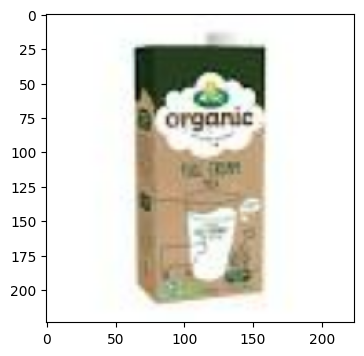

In [18]:
# ==========================================================
# Display One Image
# ==========================================================

plt.figure(figsize=(4,4))

plt.imshow(images[0].numpy().astype("uint8"))

plt.title(train_dataset.class_names[np.argmax(labels[0])])

plt.axis("off")

plt.show()

In [19]:
# Save class names before prefetch
CLASS_NAMES = [
    'bacon', 'banana', 'bread', 'broccoli', 'butter',
    'carrots', 'cheese', 'chicken', 'cucumber', 'eggs',
    'fish', 'lettuce', 'milk', 'onions', 'peppers',
    'potatoes', 'sausages', 'spinach', 'tomato', 'yogurt'
]

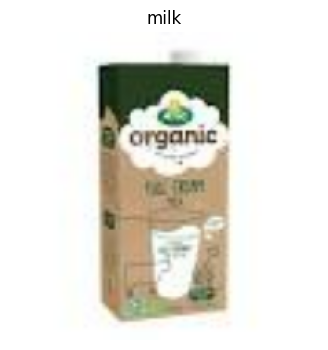

In [20]:
plt.figure(figsize=(4,4))

plt.imshow(images[0].numpy().astype("uint8"))

plt.title(CLASS_NAMES[np.argmax(labels[0])])

plt.axis("off")

plt.show()

In [21]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [22]:
MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "models",
    "food_classifier.keras"
)

early_stop = EarlyStopping(

    monitor="val_accuracy",

    patience=3,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    min_lr=1e-6

)

checkpoint = ModelCheckpoint(

    MODEL_PATH,

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

print("Callbacks Ready!")

Callbacks Ready!


In [23]:
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=5,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ]

)

Epoch 1/5
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.2203 - loss: 2.6576
Epoch 1: val_accuracy improved from None to 0.53536, saving model to C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project\models\food_classifier.keras

Epoch 1: finished saving model to C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project\models\food_classifier.keras
845/845 ━━━━━━━━━━━━━━━━━━━━ 822s 957ms/step - accuracy: 0.3569 - loss: 2.2651 - val_accuracy: 0.5354 - val_loss: 1.7162 - learning_rate: 1.0000e-04
Epoch 2/5
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.5649 - loss: 1.5811
Epoch 2: val_accuracy improved from 0.53536 to 0.59496, saving model to C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project\models\food_classifier.keras

Epoch 2: finished saving model to C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project\models\food_classifier.keras
845/845 ━━━━━━━━━━━━━━━━━━━━ 703s 831ms/step - accuracy: 0.5891 - loss: 1.4873 - val_accuracy: 0.5950 - val_loss: 1.4021 - learning_rate: 1.0000e-

In [24]:
# ==========================================================
# Unfreeze Top Layers
# ==========================================================

base_model.trainable = True

# Freeze the first 200 layers
for layer in base_model.layers[:200]:
    layer.trainable = False

print("Trainable Layers:")

trainable = 0

for layer in base_model.layers:
    if layer.trainable:
        trainable += 1

print(trainable)

Trainable Layers:
38


In [25]:
# ==========================================================
# Recompile for Fine-Tuning
# ==========================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

print("✅ Fine-Tuning Model Ready")

✅ Fine-Tuning Model Ready


In [26]:
fine_history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=10,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ]

)

Epoch 1/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 993ms/step - accuracy: 0.6421 - loss: 1.2951
Epoch 1: val_accuracy improved from 0.65382 to 0.66479, saving model to C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project\models\food_classifier.keras

Epoch 1: finished saving model to C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project\models\food_classifier.keras
845/845 ━━━━━━━━━━━━━━━━━━━━ 1007s 1s/step - accuracy: 0.6582 - loss: 1.2181 - val_accuracy: 0.6648 - val_loss: 1.1396 - learning_rate: 1.0000e-05
Epoch 2/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6911 - loss: 1.0690
Epoch 2: val_accuracy improved from 0.66479 to 0.68110, saving model to C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project\models\food_classifier.keras

Epoch 2: finished saving model to C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project\models\food_classifier.keras
845/845 ━━━━━━━━━━━━━━━━━━━━ 1022s 1s/step - accuracy: 0.6989 - loss: 1.0405 - val_accuracy: 0.6811 - val_loss: 1.0621 - learning_rate: 1.0000e-05

KeyboardInterrupt: 

In [27]:
from tensorflow.keras.models import load_model
import os

MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "models",
    "food_classifier.keras"
)

model = load_model(MODEL_PATH)

print("✅ Best Model Loaded Successfully")

✅ Best Model Loaded Successfully


In [28]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

print("✅ Model Ready")

✅ Model Ready


In [29]:
fine_history2 = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=6,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ]

)

Epoch 1/6
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7361 - loss: 0.8768
Epoch 1: val_accuracy improved from 0.70571 to 0.71312, saving model to C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project\models\food_classifier.keras

Epoch 1: finished saving model to C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project\models\food_classifier.keras
845/845 ━━━━━━━━━━━━━━━━━━━━ 1157s 1s/step - accuracy: 0.7386 - loss: 0.8703 - val_accuracy: 0.7131 - val_loss: 0.9444 - learning_rate: 1.0000e-05
Epoch 2/6
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7453 - loss: 0.8395
Epoch 2: val_accuracy improved from 0.71312 to 0.71787, saving model to C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project\models\food_classifier.keras

Epoch 2: finished saving model to C:\Users\Pranai Teja Sabbe\Desktop\AI_Diet_Project\models\food_classifier.keras
845/845 ━━━━━━━━━━━━━━━━━━━━ 1009s 1s/step - accuracy: 0.7472 - loss: 0.8334 - val_accuracy: 0.7179 - val_loss: 0.9202 - learning_rate: 1.0000e-05
Epoc

In [30]:
# ==========================================================
# Final Model Evaluation
# ==========================================================

test_loss, test_accuracy = model.evaluate(test_dataset)

print("="*60)
print("🎉 Final Test Results")
print("="*60)

print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

256/256 ━━━━━━━━━━━━━━━━━━━━ 178s 688ms/step - accuracy: 0.8066 - loss: 0.6718
🎉 Final Test Results
Test Accuracy : 80.66%
Test Loss     : 0.6718


In [31]:
# ==========================================================
# Save Final Model
# ==========================================================

import os

FINAL_MODEL = os.path.join(
    PROJECT_PATH,
    "models",
    "food_classifier_final.keras"
)

model.save(FINAL_MODEL)

print("✅ Final Model Saved!")

✅ Final Model Saved!
